In [19]:
import os
import random
import numpy as np
import torch
import torch.nn.functional as F
import torchaudio
import torchvision
import torchtext
import torch.nn as nn
import pandas as pd
import jupyterlab as jlab
import matplotlib as mpl
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import datasets, transforms
from torchvision.transforms import v2
from torchvision.utils import save_image
from torchaudio.transforms import Spectrogram, Resample
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import vocab

from PIL import Image

from collections import OrderedDict
from typing import List, Dict, Optional

from dataclasses import dataclass, field

In [2]:

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = datasets.CIFAR10(root="./data", train = True, download = True, transform = transform) 

Files already downloaded and verified


In [5]:
batch_size = 4
data_loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

images, labels = next(iter(data_loader))
print("Форма батча изображений:", images.shape) 
print("Метки батча:", labels)

Форма батча изображений: torch.Size([4, 3, 128, 128])
Метки батча: tensor([5, 4, 9, 9])


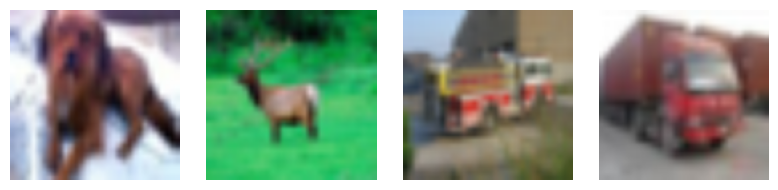

In [6]:
def show_images(images, cols=4):
    """
    Display a grid of images with labels.
    images: torch.Tensor of shape [N, C, H, W] (values in [0,1])
    """
    rows = (batch_size + cols - 1) // cols  # Calculate rows needed
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten() if batch_size > 1 else [axes]
    
    for i in range(batch_size):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        
        axes[i].imshow(img)
        axes[i].axis('off')

    for i in range(batch_size, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()


show_images(images, cols=4)

### ColorJitter

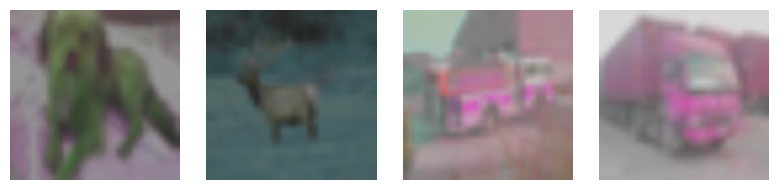

In [22]:
def apply_jitter_show(images, brightness=0.6, contrast=0.6, saturation=0.6, hue=0.25, cols=4):
    jitter = v2.ColorJitter(
        brightness=brightness,  
        contrast=contrast,    
        saturation=saturation,  
        hue= hue      
    )
    rows = (batch_size + cols - 1) // cols 
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten() if batch_size > 1 else [axes]
    
    for i in range(batch_size):
        jitt_img = jitter(images[i])
        img = jitt_img.permute(1, 2, 0).cpu().numpy()
        
        axes[i].imshow(img)
        axes[i].axis('off')

    for i in range(batch_size, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
        
apply_jitter_show(images)

изменение яркости, контрастности, насыщенности и цвета не влияет на суть объектов на фото, собака остается собакой, машина машиной, объекты остаются различимыми,

но из-за того что меняются цвета, картинка может стать неправдоподобной(например собака стала зеленой, а листва на второй картинке синей),

поэтому нужно быть осторожным с аугментацией данных при помощи ColorJitter, если мы хотим обращать внимание на цвет объектов на картинках

### FiveCrop

In [ ]:
def five_crop_and_show(images, size=16, cols=4)

    five_crop = v2.FiveCrop(size)

    rows = (batch_size + cols - 1) // cols 

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten() if batch_size > 1 else [axes]

    for i in range(batch_size):
        jitt_img = five_crop(images[i])
        img = jitt_img.permute(1, 2, 0).cpu().numpy()
        
        axes[i].imshow(img)
        axes[i].axis('off')

    for i in range(batch_size, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()